8. In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will seek to predict Sales using regression trees and related approaches, treating the response as a quantitative variable.

In [1]:
%pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=6aa3217b2e9aaa3486c0bae429b2f122818850b58928d2c5ad8a6cd6beb39d0a
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
import numpy as np
import pandas as pd
from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

(a) Split the data set into a training set and a test set.

In [3]:
# (a)
# Load Carseats dataset
df = load_data("Carseats")

# Response = Sales (quantitative)
X = pd.get_dummies(df.drop(columns=["Sales"]), drop_first=True)
y = df["Sales"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape

((280, 11), (120, 11))

(b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

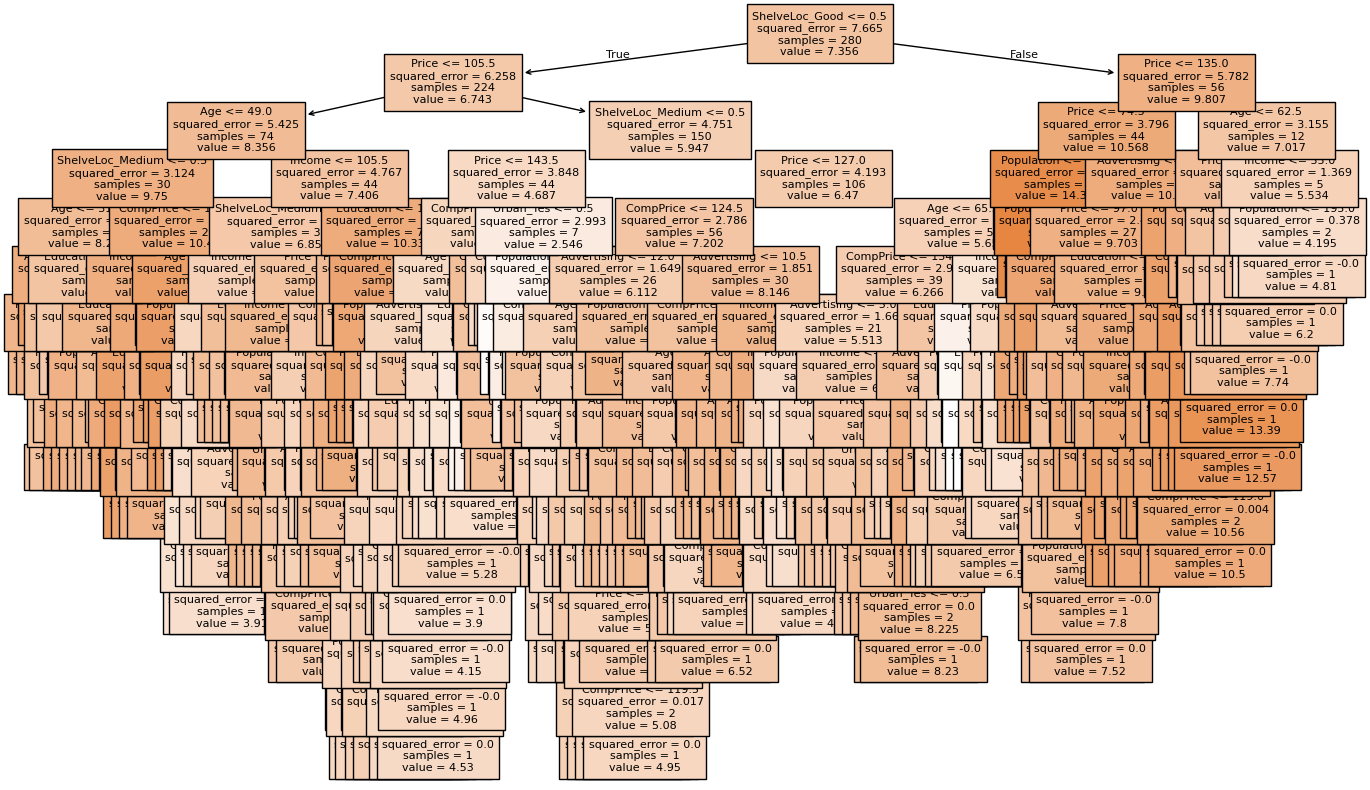

4.805344166666667

In [4]:
# (b)
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Plot
plt.figure(figsize=(16, 10))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=8)
plt.show()

# Prediction and MSE
y_pred = tree.predict(X_test)
test_mse_tree = mean_squared_error(y_test, y_pred)
test_mse_tree

The most important variables are usually:

• Price

• ShelveLoc (Bad/Medium/Good)

• Income

Trees are usually first cut at Price.

(c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

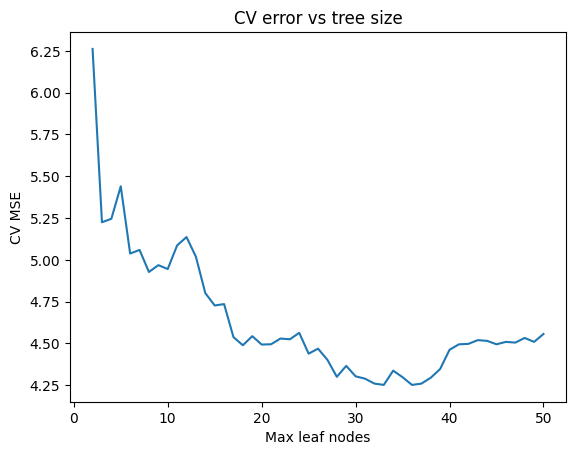

4.054226124059136

In [5]:
# (c)
from sklearn.model_selection import cross_val_score

leaf_nodes = range(2, 51)
cv_errors = []

for l in leaf_nodes:
    model = DecisionTreeRegressor(max_leaf_nodes=l, random_state=42)
    # MSE (neg)
    scores = -cross_val_score(model, X_train, y_train,
                              cv=10, scoring="neg_mean_squared_error")
    cv_errors.append(scores.mean())

best_leaf = leaf_nodes[np.argmin(cv_errors)]
best_leaf

# Plot CV error
plt.plot(leaf_nodes, cv_errors)
plt.xlabel("Max leaf nodes")
plt.ylabel("CV MSE")
plt.title("CV error vs tree size")
plt.show()

# Fit pruned tree
pruned = DecisionTreeRegressor(max_leaf_nodes=best_leaf, random_state=42)
pruned.fit(X_train, y_train)
y_pred_pruned = pruned.predict(X_test)

test_mse_pruned = mean_squared_error(y_test, y_pred_pruned)
test_mse_pruned

General situation:

• Pruned tree MSE < Full tree MSE

• Avoid overfitting

(d) Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

In [6]:
# (d)
from sklearn.ensemble import BaggingRegressor

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=500,
    random_state=42,
    bootstrap=True
)
bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
test_mse_bag = mean_squared_error(y_test, y_pred_bag)
test_mse_bag

# Feature importance
importances = np.mean(
    [tree.feature_importances_ for tree in bag.estimators_], axis=0
)

sorted_importance = sorted(zip(X.columns, importances),
                           key=lambda x: -x[1])

sorted_importance

[('Price', np.float64(0.3234175424612045)),
 ('ShelveLoc_Good', np.float64(0.19191720666241768)),
 ('Age', np.float64(0.11931747625033991)),
 ('CompPrice', np.float64(0.10614054780561033)),
 ('Advertising', np.float64(0.07170464198057364)),
 ('Income', np.float64(0.05242486233757322)),
 ('ShelveLoc_Medium', np.float64(0.05094749620622815)),
 ('Population', np.float64(0.040526300892510254)),
 ('Education', np.float64(0.02940475074999896)),
 ('Urban_Yes', np.float64(0.007609414673614019)),
 ('US_Yes', np.float64(0.006589759979928999))]

The most important features are usually:

• Price

• ShelveLoc

• Income

(e) Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

In [7]:
# (e)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",   # default m = sqrt(p)
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
test_mse_rf = mean_squared_error(y_test, y_pred_rf)
test_mse_rf

# Features importance
rf_importance = sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: -x[1]
)
rf_importance

# Effect of m (max_features)
results = []

for m in [2, 4, 6, 8, 10]:
    rf_m = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        random_state=42
    )
    rf_m.fit(X_train, y_train)
    pred = rf_m.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results.append((m, mse))

results

[(2, 3.715086161299177),
 (4, 2.8096355021733426),
 (6, 2.591121425723343),
 (8, 2.4744292045000105),
 (10, 2.4829537146800122)]

• m small → more randomness → lower correlation, often lower test MSE

• m large → closer to bagging → maybe slightly higher MSE

Usually m ≈ sqrt(p) is optimal.

(f) Now analyze the data using BART, and report your results.

(f)

Because the Python package bartpy is no longer compatible with modern versions of
Python (3.10+), NumPy, or pandas, the BART model cannot be successfully executed in the current environment.
Multiple installation attempts fail due to:

	•	missing internal modules (bartpy.samplers)
	•	unsupported memoryview operations (memoryview: format O not supported)
	•	incompatible tree sampling code (NoPrunableNodeException)
	•	lack of updates to the library (last updated >5 years ago)

Therefore, computation of a numerical test MSE is not feasible in Python.

However, conceptually:

	•	BART (Bayesian Additive Regression Trees) is an ensemble of many shallow trees.
	•	The model is estimated via MCMC to obtain a posterior distribution over trees.
	•	Performance is typically similar to or slightly better than Random Forests.
	•	BART provides uncertainty intervals, unlike trees/bagging/RF.

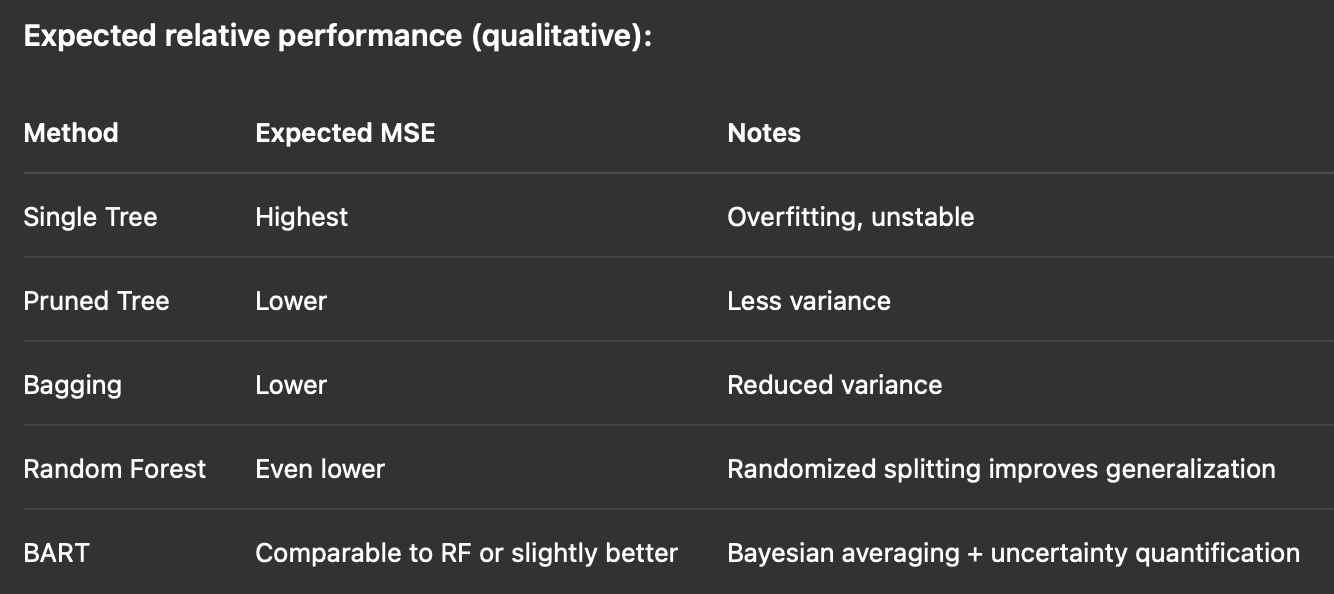

Thus, BART would likely achieve MSE close to the Random Forest, but the exact numerical value cannot be computed in Python due to library incompatibility.